# Milestone 2 solution: Loading and cleaning the data

### Objective

-  Perform an exploratory analysis on the San Francisco safety data to understand general trends, recurrent events, and most frequent event locations in the city.
-  Compute city neighborhood name for each safety event.

In [1]:
# this plugin requires to run "pip install nb-black"
%load_ext nb_black

<IPython.core.display.Javascript object>

In [2]:
import pandas as pd

import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>

In [3]:
df = pd.read_parquet("../data/safety-SanFrancisco-1.parquet")

<IPython.core.display.Javascript object>

In [4]:
df.shape

(3958888, 10)

<IPython.core.display.Javascript object>

In [5]:
df.head()

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source
0,1,911_Fire,2018-10-02 11:54:01,Potentially Life-Threatening,Medical Incident,None,ELM ST/FRANKLIN ST,37.781286,-122.422187,NaN
1,2,311_All,2018-07-08 15:00:27,Street and Sidewalk Cleaning,Bulky Items,Closed,"1536 SACRAMENTO ST, SAN FRANCISCO, CA, 94109",37.791887,-122.418188,Mobile/Open311
2,3,311_All,2016-06-28 13:12:28,General Request - COUNTY CLERK,customer_callback,Closed,Not associated with a specific address,0.000000,0.000000,Phone
3,7,311_All,2017-03-03 09:34:49,Temporary Sign Request,Temporary Sign Request for Other_Event_Type,Closed,"2190 NORTH POINT ST, SAN FRANCISCO, CA, 94123",37.802853,-122.443245,Phone
4,10,911_Fire,2016-10-25 18:33:20,Potentially Life-Threatening,Medical Incident,None,200 Block of DALEWOOD WAY,37.737953,-122.456498,NaN


<IPython.core.display.Javascript object>

## 1. Exploratory analysis

We start by selecting 5 most frequent event categories for our exploratory analysis,

In [6]:
df["category"].value_counts().head()

Street and Sidewalk Cleaning    965968
Potentially Life-Threatening    676296
Non Life-threatening            349634
Alarm                           326893
Graffiti                        296927
Name: category, dtype: int64

<IPython.core.display.Javascript object>

In [7]:
categories = df["category"].value_counts().head(5).index

<IPython.core.display.Javascript object>

The first thing we can look at is how the number of events evolves with time. Below are the number of weekly events for 5 most frequent categories.
"Street and Sidewalk cleaning" and "Encampments" categories show a clear increase over the years, with a characteristic spike around New Year for the former category. 

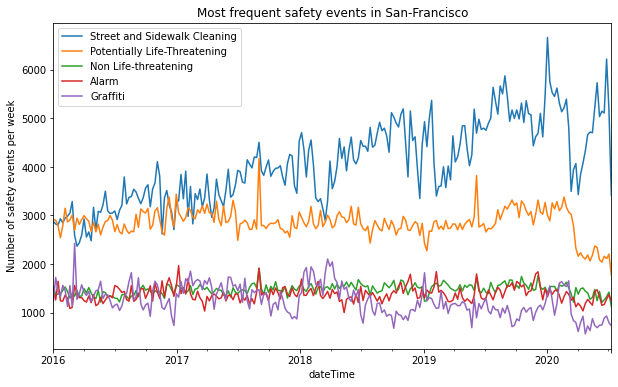

<IPython.core.display.Javascript object>

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for name in categories:
    mask = df["category"] == name
    df[mask].groupby(pd.Grouper(key="dateTime", freq="7D"))["requestId"].count().plot(
        ax=ax, label=name
    )
ax.legend(loc="best")
ax.set_ylabel("Number of safety events per week")
_ = ax.set_title("Most frequent safety events in San-Francisco")

**Evaluating periodicity of events**

On the previous figure, we can see some repeated trends from year to year. To make this dependence more clear, we can aggregate the number of events by month, week day and hour.

To make the visualization more comparable between categories, we will visualize the relative frequency of events by dividing the number of monthly events by the largest number of events in a given month.

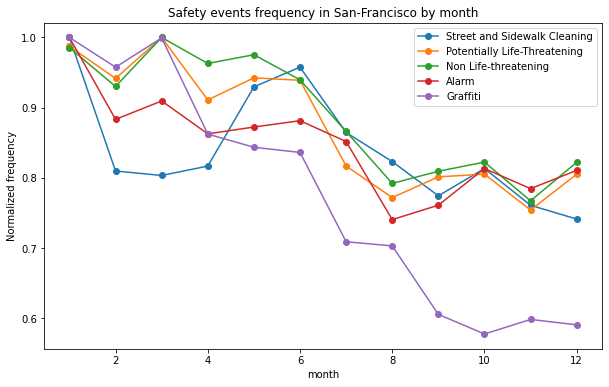

<IPython.core.display.Javascript object>

In [9]:
def plot_periodicity(df, ax, categories, period="month"):
    for name in categories:
        mask = df["category"] == name
        group = getattr(df["dateTime"].dt, period)
        res = df[mask].groupby(group)["requestId"].count()
        (res / res.max()).plot.line(ax=ax, label=name, marker="o")
    ax.legend(loc="best")
    ax.set_title(f"Safety events frequency in San-Francisco by {period}")
    ax.set_xlabel(period)
    ax.set_ylabel("Normalized frequency")


fig, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_periodicity(df, ax, categories, period="month")

For aggregations by month, we have to be careful with the interpretation as the  year to year trend is not subtracted. Nevertheless, we see a pronounced peak for "Encampments" in August as well a general decrease of "Graffiti" events later in the year.

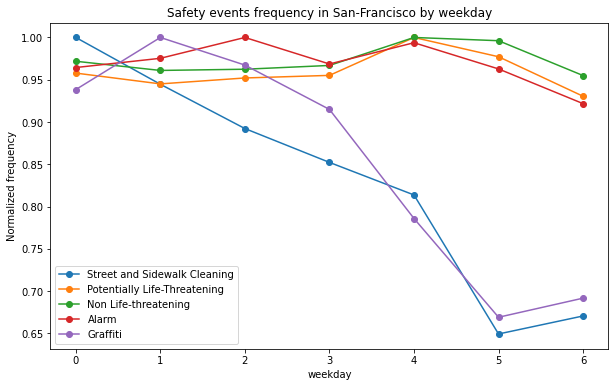

<IPython.core.display.Javascript object>

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_periodicity(df, ax, categories, period="weekday")

All events except for "non life-threatening" and "potentially life threatening" show a decrease over the week and particularly on the weekend. On the above figure week days are encoded as Monday=0 to Sunday=6.

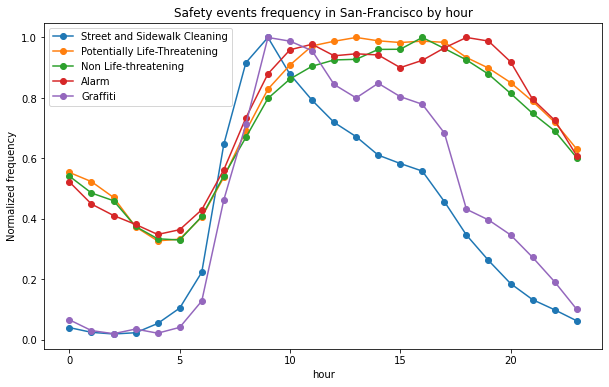

<IPython.core.display.Javascript object>

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_periodicity(df, ax, categories, period="hour")

Finally, as we would expect except for "non life-threatening" and "potentially life threatening" there is mostly no events reported during the night. These two categories have a maximum in the afternoon, while the three remaining events have a spike in the morning with a gradual decrease during the day

**Event status statistics**

It's also interesting to explore the interaction of `category` with other columns in the data, for instance `status` and `source`.

In [12]:
group_cols = ["requestId", "category", "status"]
mask = df["category"].isin(categories)

# We convert the data to "str" dtype, to include NaN in the group by results.
# Otherwise they would be ignored.
df.loc[mask, group_cols].astype("str").groupby(["category", "status"])[
    "requestId"
].count()

category                      status
Alarm                         None      326893
Graffiti                      Closed    294473
                              Open        2454
Non Life-threatening          None      349634
Potentially Life-Threatening  None      676296
Street and Sidewalk Cleaning  Closed    963931
                              Open        2037
Name: requestId, dtype: int64

<IPython.core.display.Javascript object>

"Non Life-threatening" and "Potentially Life-Threatening" don't have a status, likely because they always needs responding to.

As to the other categories most events have a "closed" status, with "Graffiti" showing the highest fraction of events with an "open" status (around 7%).

In [13]:
group_cols = ["requestId", "category", "source"]
mask = df["category"].isin(categories)

df.loc[mask, group_cols].astype("str").groupby(["category", "source"])[
    "requestId"
].count()

category                      source           
Alarm                         nan                  326893
Graffiti                      Integrated Agency     17618
                              Mobile/Open311       212181
                              Other Department          2
                              Phone                 19041
                              Twitter                 699
                              Web                   47386
Non Life-threatening          nan                  349634
Potentially Life-Threatening  nan                  676296
Street and Sidewalk Cleaning  Email                     2
                              Integrated Agency     41869
                              Mobile/Open311       567441
                              Other Department         93
                              Phone                276629
                              Twitter                5254
                              Web                   74680
Name: requestId, dtype: 

<IPython.core.display.Javascript object>

More events reports originate from either [Open311 mobile app](http://www.open311.org/) or phone calls.

## 2. Geographic distribution of events

To visualize geographic distributions of events, we select a arbitrary date, for instance 20 January 2019. The first approach is simply to display a scatter plot of GPS coordinates for events on this day. 

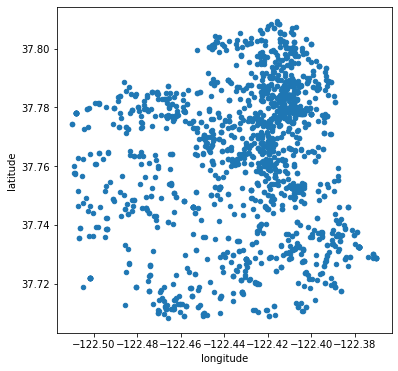

<IPython.core.display.Javascript object>

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

mask = (
    (df["dateTime"] >= pd.to_datetime("2019-01-20"))
    & (df["dateTime"] < pd.to_datetime("2019-01-21"))
    # We need to filter out points with (0, 0) GPS coordinates
    # identified in an earlier milestone
    & (df["latitude"] != 0.0)
    & (df["longitude"] != 0.0)
)
df[mask].plot.scatter(y="latitude", x="longitude", ax=ax)

We observe that there are some denser clusters on the figure, but overall results are difficult to interpret without displaying this data on a map.

To visualize it on a map, we use the [pyleaflet](https://github.com/jupyter-widgets/ipyleaflet) package. Because there are more than 1000 events on that day, displaying each individual point as a pyleaflet `Marker` takes long time to plot and makes the resulting figure cluttered. Instead we use the `MarkerCluster` class to group closely positioned events together into clusters.

In [15]:
from ipyleaflet import Map, Marker, MarkerCluster

<IPython.core.display.Javascript object>

In [16]:
dates = ("2019-01-20", "2019-01-21")
category = "Potentially Life-Threatening"

mask = (
    (df["dateTime"] >= pd.to_datetime(dates[0]))
    & (df["dateTime"] < pd.to_datetime(dates[1]))
    & (df["latitude"] != 0.0)
    & (df["longitude"] != 0.0)
    & (df["category"] == category)
)

# we center the map on the centroid of all events
center = list(df.loc[mask, ["latitude", "longitude"]].median(axis=0))


m = Map(center=center, zoom=11.5)
print(f"Rendering map for {dates[0]} - {dates[1]} and category={category}")
markers = [
    Marker(location=(x, y)) for (x, y) in df.loc[mask, ["latitude", "longitude"]].values
]

cl = MarkerCluster(markers=markers)
m.add_layer(cl)

m

Rendering map for 2019-01-20 - 2019-01-21 and category=Potentially Life-Threatening


Map(center=[37.778518830995, -122.41571987823], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zo…

<IPython.core.display.Javascript object>

This is an interactive figure and you can explore the map or zoom in to see individual event locations. 

### Interactive Jupyter widget

To make this visualization even more interactive we can add a dropdown with the category by adapting [this ipyleaflet example](https://github.com/jupyter-widgets/ipyleaflet/blob/master/examples/DropdownControl.ipynb). Similarly we could add a [ipywidget slider](https://ipywidgets.readthedocs.io/en/latest/examples/Widget%20List.html#IntSlider) to select the date, however it would require more work and we can dedicate only limited time to spend on this milestone.

In [17]:
from ipywidgets import Dropdown
from ipyleaflet import WidgetControl


center = list(df[["latitude", "longitude"]].median(axis=0))

# we define dates as a global object to pass it to on_click handler
dates = ("2019-01-20", "2019-01-21")


def make_markers(df, category):

    mask = (
        (df["dateTime"] >= pd.to_datetime(dates[0]))
        & (df["dateTime"] < pd.to_datetime(dates[1]))
        & (df["latitude"] != 0.0)
        & (df["longitude"] != 0.0)
        & (df["category"] == category)
    )
    markers = [
        Marker(location=(x, y))
        for (x, y) in df.loc[mask, ["latitude", "longitude"]].values
    ]
    return markers


def make_map(df, center):
    print(f"Rendering map for {dates[0]} - {dates[1]}")
    m = Map(center=center, zoom=11.5)
    markers = make_markers(df, list(categories)[0])

    cl = MarkerCluster(markers=markers)
    m.add_layer(cl)
    return m


m = make_map(df, center,)


# Handles Dropdown control event
def on_click(change):
    category_name = change["new"]
    old_layer = m.layers[-1]
    markers = make_markers(df, category_name)
    cl = MarkerCluster(markers=markers)
    m.substitute_layer(old_layer, cl)


dropdown = Dropdown(
    options=list(categories), value=list(categories)[0], description="Category"
)
dropdown.observe(on_click, "value")

basemap_control = WidgetControl(widget=dropdown, position="topright")
m.add_control(basemap_control)

m

Rendering map for 2019-01-20 - 2019-01-21


Map(center=[37.770629882813, -122.41890255760904], controls=(ZoomControl(options=['position', 'zoom_in_text', …

<IPython.core.display.Javascript object>

## 3. Compute the city neighborhood name for each event location.


To compute the neighborhood name for each GPS location, we first download the GeoJSON with San Fransisco neighborhood information using `urllib.request.urlopen` then load it with the json module.

In [18]:
import urllib.request
import json

url = "https://gist.githubusercontent.com/rth/403f672baf26beef91285c8079e1d257/raw/ebe3d2a4eda405775a860d251974e1f08cbe4f48/SanFrancisco.Neighborhoods.json"
with urllib.request.urlopen(url) as response:
    sf_ngh = json.loads(response.read())

<IPython.core.display.Javascript object>

This GeoJSON is a nested dict, where `features` is a list of neighborhoods. Each neighborhood has by a name and contains a list of coordinates that define it's border.

In [19]:
sf_ngh

{'type': 'FeatureCollection',
 'features': [{'geometry': {'geometries': [{'type': 'Polygon',
      'coordinates': [[[-122.391701, 37.794113],
        [-122.39198, 37.793906],
        [-122.391614, 37.793571],
        [-122.391714, 37.793459],
        [-122.388816, 37.791005],
        [-122.388932, 37.790919],
        [-122.388616, 37.790348],
        [-122.388076, 37.790518],
        [-122.388375, 37.790334],
        [-122.388225, 37.790032],
        [-122.385852, 37.790951],
        [-122.385496, 37.790559],
        [-122.387589, 37.789838],
        [-122.387289, 37.789347],
        [-122.385303, 37.789838],
        [-122.38512, 37.789313],
        [-122.387174, 37.788807],
        [-122.387032, 37.788255],
        [-122.385261, 37.788537],
        [-122.385136, 37.788156],
        [-122.38739, 37.787736],
        [-122.387415, 37.787269],
        [-122.3845, 37.787437],
        [-122.384342, 37.785728],
        [-122.387577, 37.785485],
        [-122.38765, 37.784929],
        [-122.

<IPython.core.display.Javascript object>

Count the number of neighborhoods

In [20]:
len(sf_ngh["features"])

23

<IPython.core.display.Javascript object>

Let's extract the border coordinates for the first neighborhood,

In [21]:
import numpy as np

neighborhood = sf_ngh["features"][0]

print(neighborhood["properties"]["neighborhood"])
sf_ngh_border = np.array(neighborhood["geometry"]["geometries"][0]["coordinates"][0])
sf_ngh_border[:10]

Rincon Hill


array([[-122.391701,   37.794113],
       [-122.39198 ,   37.793906],
       [-122.391614,   37.793571],
       [-122.391714,   37.793459],
       [-122.388816,   37.791005],
       [-122.388932,   37.790919],
       [-122.388616,   37.790348],
       [-122.388076,   37.790518],
       [-122.388375,   37.790334],
       [-122.388225,   37.790032]])

<IPython.core.display.Javascript object>

Then for each GPS coordinates, we need to compute whether they are inside or outside this polygon

In [22]:
df[["longitude", "latitude"]].head()

,longitude,latitude
0,-122.422187,37.781286
1,-122.418188,37.791887
2,0.000000,0.000000
3,-122.443245,37.802853
4,-122.456498,37.737953


<IPython.core.display.Javascript object>

This is a typical geo-spatial task and specialized software e.g. [geopandas](https://geopandas.org/) excel at it, however here for simplicity we will use the `contains_points` method of `matplotlib.path.Path`, since we already have matplotlib installed.

In [23]:
import matplotlib.path as mpl_path

res = mpl_path.Path(sf_ngh_border).contains_points(df[["longitude", "latitude"]])
res

array([False, False, False, ..., False, False, False])

<IPython.core.display.Javascript object>

This returns a boolean mask, indicating for each point whether it's inside the neighborhood.

In [24]:
res.sum()

83938

<IPython.core.display.Javascript object>

Now we can simply loop over the neighborhoods stored in the GeoJSON and store the result into a new column

In [25]:
df["neighborhood"] = np.full(len(df), np.nan, dtype="object")

for feature in sf_ngh["features"]:
    name = feature["properties"]["neighborhood"]
    print(f"Processing neighborhood: {name}")
    # we use np.squeeze to drop any single dimensional entries from the shape of the array
    # e.g. convert (1, n, 2) to (n, 2)
    border = np.squeeze(np.array(feature["geometry"]["geometries"][0]["coordinates"]))
    if border.ndim != 2:
        # If the dimensionality of the neighborhood border is not 2, it likely requires
        # special handling. We skip it for now, and this might require more investigation
        # later.
        print(f"wrong number of dimensions={border.shape}!=2 skipping")
        continue
    mask = mpl_path.Path(border).contains_points(df[["longitude", "latitude"]])
    df.loc[mask, "neighborhood"] = name

Processing neighborhood: Rincon Hill
Processing neighborhood: South Beach
Processing neighborhood: Chinatown
Processing neighborhood: Nob Hill
Processing neighborhood: Ingleside
Processing neighborhood: Castro
Processing neighborhood: Sunset
Processing neighborhood: Bayview
Processing neighborhood: Portola
Processing neighborhood: Lake Merced
Processing neighborhood: Twin Peaks
Processing neighborhood: North Beach
Processing neighborhood: Tenderloin
Processing neighborhood: SoMa
Processing neighborhood: Mission
Processing neighborhood: Financial District
Processing neighborhood: Lower Pacific Heights
Processing neighborhood: Taraval
Processing neighborhood: Panhandle
Processing neighborhood: Inner Richmond
Processing neighborhood: Outer Richmond
wrong number of dimensions=(3,)!=2 skipping
Processing neighborhood: Marina
Processing neighborhood: Bayshore


<IPython.core.display.Javascript object>

In [26]:
df["neighborhood"].value_counts()

SoMa                     462350
Mission                  451230
Tenderloin               343504
Nob Hill                 281070
Ingleside                202975
Bayview                  200126
Castro                   178582
Panhandle                178199
South Beach              163293
Sunset                   153924
Bayshore                 128494
North Beach              122645
Inner Richmond           120657
Lower Pacific Heights    115798
Chinatown                 92384
Rincon Hill               83918
Taraval                   82293
Marina                    75512
Twin Peaks                68742
Lake Merced               63114
Financial District        48113
Portola                   37591
Name: neighborhood, dtype: int64

<IPython.core.display.Javascript object>

The neighborhood for 8% of samples couldn't be determined. This might require more investigation in the future, possibly the data points are outside city boundaries as specified by GeoJSON, or our matching approach is imperfect. Using specialized geo-spatial software would likely help, but it's a larger task.  

In [27]:
df["neighborhood"].isna().sum() / df.shape[0]

0.07688371077939057

<IPython.core.display.Javascript object>

Below is an example of results on a few selected columns,

In [28]:
df[["category", "dateTime", "longitude", "latitude", "neighborhood"]].sample(
    5, random_state=2
)

,category,dateTime,longitude,latitude,neighborhood
3631370,General Request - MTA,2016-12-21 11:20:58,-122.393835,37.782702,South Beach
13847,Street and Sidewalk Cleaning,2017-03-06 10:57:29,-122.408258,37.774712,SoMa
3859479,Street and Sidewalk Cleaning,2017-10-28 16:19:00,-122.460030,37.714196,Ingleside
583162,Street and Sidewalk Cleaning,2019-12-29 13:18:00,-122.388963,37.729976,Bayview
2495195,Residential Building Request,2019-05-11 19:45:00,-122.438667,37.714348,Ingleside


<IPython.core.display.Javascript object>

Finally we can store the resulting dataframe on disk,

In [29]:
df.to_parquet("../data/safety-SanFrancisco-2.parquet")

<IPython.core.display.Javascript object>